# Alunos
- **Matheus Peixoto Ribeiro Vieira - 22.1.4104**
- **Pedro Henrique Rabelo Leão de Oliveira - 22.1.4022**

# Objetivo do desafio
A partir de uma base de dados com partidas do campeonato brasileiro de futebol desde o ano 2012 até atualmente, o objetivo é predizer o resultado de um novo confronto, dizendo se a partida acabará em vitória de um dos times ou em empate.

In [12]:
import pandas as pd
import json
pd.set_option('display.max_columns', 100)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from scipy.stats import gaussian_kde, norm

import seaborn as sns

# 0 - Formatando o dataset e adicionando novas colunas

In [13]:
!wget https://www.football-data.co.uk/new/BRA.csv -O ./data/BRA.csv

--2025-07-06 21:07:17--  https://www.football-data.co.uk/new/BRA.csv
Resolving www.football-data.co.uk (www.football-data.co.uk)... 217.160.0.246
Connecting to www.football-data.co.uk (www.football-data.co.uk)|217.160.0.246|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 561339 (548K) [text/csv]
Saving to: ‘./data/BRA.csv’

./data/BRA.csv      100%[===================>] 548.18K   501KB/s    in 1.1s    

2025-07-06 21:07:19 (501 KB/s) - ‘./data/BRA.csv’ saved [561339/561339]



| Atributo | Tipo do Atributo   | Descrição do Atributo |
|----------|------------------  |------------------------|
| Country  | Categórico nominal | Indica o país que a partida ocorreu |
| League   | Categórico nominal | Indica qual o campeonato em questão |
| Seasons  | Categórico nominal | Indica a temporada da partida |
| Date     | Categorico nominal | Data da partida
| Time     | Categorico nominal | Hora da partida
| Home     | Categórico nominal | ID único para o time mandante |
| Away     | Categórico nominal | ID único para o time visitante |
| HG       | Discreto           | Quantidade de gols do time mandante |
| AG       | Discreto           | Quantidade de gols do time visitante |
| Res      | Categórico nominal | Resultado da partida |
| PSCH     | Contínuo           | Odd de vitória do time mandante na Pinnacle Sports |
| PSCD     | Contínuo           | Odd de empate na Pinnacle Sports |
| PSCA     | Contínuo           | Odd de vitória do time visitante na Pinnacle Sports |
| MaxCH    | Contínuo           | Odd máxima de vitória do time mandante no mercado |
| MaxCD    | Contínuo           | Odd máxima de empate no mercado |
| MaxCA    | Contínuo           | Odd máxima de vitória do time visitante no mercado |
| AvgCH    | Contínuo           | Valor médio das odds para vitória do time mandante |
| AvgCD    | Contínuo           | Valor médio das odds para empate |
| AvgCA    | Contínuo           | Valor médio das odds para vitória do time visitante |
| BFECH    | Contínuo           | Odds da BetFair para vitória do time mandante
| BFECD    | Contínuo           | Odds da BetFair para empate
| BFECA    | Contínuo           | Odds da BetFair para vitória do time visitante

Transformando o nome dos times para valores numéricos, removendo as últimas três colunas que tem muitos valores vazios, acrescentando novas colunas com valores estatísticos sobre os times até aquela rodada do campeonato

In [14]:
class Queue:
    def __init__(self, max_values=5):
        self.results = [None] * max_values
        self.max_values = max_values
        self.counter = 0

    def insert(self, item):
        assert item=="w" or item=="d" or item=="l"
        # Insert itens in a circular queue
        index = self.counter % self.max_values
        self.results[index] = item
        self.counter += 1

    def get_results(self):
        results_dict = {'w': 0, 'd': 0, 'l': 0, None: 0}
        for i in self.results:
            results_dict[i] += 1
        return results_dict

def map_names_to_ids(df):
    """
        Receives a DataFrame with the Brasileirao data
        Combines all the teams' names from Home and Away and set them to an unique ID
    """
    # Combine both columns to get all unique names
    all_names = pd.concat([df['Home'], df['Away']]).unique()
    all_names = sorted(all_names)

    # Mapping the id to a name
    mapped_names = {name: i for i, name in enumerate(all_names)}
    df['Home'] = df['Home'].map(mapped_names)
    df['Away'] = df['Away'].map(mapped_names)

    return df, mapped_names

def save_mapped_ids(mapped_names, target_csv):
    # Saving the mapping of the teams IDs
    file_name = target_csv[:-4] + ".json"
    with open(file_name, "w") as file:
        json.dump(mapped_names, file, indent=4)


def add_new_columns(df: pd.DataFrame):
    for H_A in ["H", "A"]:
        df[f'W_{H_A}'] = 0
        df[f'D_{H_A}'] = 0
        df[f'L_{H_A}'] = 0
        df[f'GF_{H_A}'] = 0
        df[f'GA_{H_A}'] = 0
        df[f'GD_{H_A}'] = 0
    
    return df


def resetTeamStatisticsDict(mapped_names, teamStatistics):
    
    for idTeam in list(mapped_names.values()):
        # del teamStatistics[idTeam]['LF']
        teamStatistics[idTeam] = {
            'W': 0,   # Wons
            'D': 0,   # Drawn
            'L': 0,   # Loses
            'GF': 0,  # Goals For
            'GA': 0,  # Goals Against
            'GD': 0,  # Goal Difference
            'LF': Queue() # The last five matches results
        }


def updateStatistics(teamStatistics, home, away, goals_home, goals_away):
    """
        Function to update the team statistics with data from the previous round
    """

    teamStatistics[home]['GF'] += goals_home
    teamStatistics[home]['GA'] += goals_away
    teamStatistics[home]['GD'] += goals_home - goals_away

    teamStatistics[away]['GF'] += goals_away
    teamStatistics[away]['GA'] += goals_home
    teamStatistics[away]['GD'] += goals_away - goals_home

    # Home team wins
    if goals_home > goals_away:
        teamStatistics[home]['W'] += 1
        teamStatistics[home]['LF'].insert('w')
        teamStatistics[away]['L'] += 1
        teamStatistics[away]['LF'].insert('l')

    # Away team wins
    elif goals_away > goals_home:
        teamStatistics[home]['L'] += 1
        teamStatistics[home]['LF'].insert('l')
        teamStatistics[away]['W'] += 1
        teamStatistics[away]['LF'].insert('w')

    # Drawn
    else:
        teamStatistics[home]['D'] += 1
        teamStatistics[home]['LF'].insert('d')
        teamStatistics[away]['D'] += 1
        teamStatistics[away]['LF'].insert('d')


def make_statistics(df: pd.DataFrame, mapped_names: dict):
    """

    """
    df = add_new_columns(df)

    teamStatistics = {}
    resetTeamStatisticsDict(mapped_names, teamStatistics)
    
    current_year = df.iloc[0]["Season"]
    
    for index, row in df.iterrows():
        if row["Season"] != current_year:
            current_year = row["Season"]
            resetTeamStatisticsDict(mapped_names, teamStatistics)
        
        home_id = row["Home"]
        away_id = row["Away"]
        
        # Saving the statistics from the season until the current game
        for h_a, id in [("H", home_id), ("A", away_id)]:
            for stat in ["W", "D", "L", "GF", "GA", "GD"]:
                df.loc[index, f"{stat}_{h_a}"] = teamStatistics[id][stat]

            last_five_results = teamStatistics[id]['LF'].get_results()
            df.loc[index, f"WLF_{h_a}"] = last_five_results['w']
            df.loc[index, f"DLF_{h_a}"] = last_five_results['d']
            df.loc[index, f"LLF_{h_a}"] = last_five_results['l']

        # Updating statistics
        home_goals = row["HG"]
        away_goals = row["AG"]

        updateStatistics(teamStatistics, home_id, away_id, home_goals, away_goals)

    return df


def update_csv(original_csv, target_csv):
    """
        Receives the CSV file with the Brasileirao data
        Updates the columns 'Home' and 'Away' from nominal values to numerical.
        It will attribue an ID to each team
    """
    
    df = pd.read_csv(original_csv)

    df, mapped_names = map_names_to_ids(df)

    save_mapped_ids(mapped_names, target_csv)
    
    # Removing the last three columns which have many empty values
    df = df.drop(["Country", "League", "Date", "Time", "BFECH", "BFECD", "BFECA"], axis=1)
    
    
    df = make_statistics(df, mapped_names)
    
    df.to_csv(target_csv, index=False)


update_csv("data/BRA.csv", "data/BRA-modified.csv")

Remoção de Country e League que é igual para todos os atributos

Remoção de Date e Time que não são relevantes

Remoção de BFECH, BFECD e BFECA, pois a maioria de seus valores são nulos

# 1 - Análise descritiva dos atributos

In [15]:
df = pd.read_csv("./data/BRA-modified.csv")

## a) Descrição dos atributos

| Atributo | Tipo do Atributo | Descrição do Atributo |
|----------|------------------|------------------------|
| Seasons  | Categórico nominal         | Indica a temporada da partida |
| Home     | Categórico nominal | ID único para o time mandante |
| Away     | Categórico nominal | ID único para o time visitante |
| HG       | Discreto         | Quantidade de gols do time mandante |
| AG       | Discreto         | Quantidade de gols do time visitante |
| Res      | Categórico nominal | Resultado da partida |
| PSCH     | Contínuo         | Odd de vitória do time mandante na Pinnacle Sports |
| PSCD     | Contínuo         | Odd de empate na Pinnacle Sports |
| PSCA     | Contínuo         | Odd de vitória do time visitante na Pinnacle Sports |
| MaxCH    | Contínuo         | Odd máxima de vitória do time mandante no mercado |
| MaxCD    | Contínuo         | Odd máxima de empate no mercado |
| MaxCA    | Contínuo         | Odd máxima de vitória do time visitante no mercado |
| AvgCH    | Contínuo         | Valor médio das odds para vitória do time mandante |
| AvgCD    | Contínuo         | Valor médio das odds para empate |
| AvgCA    | Contínuo         | Valor médio das odds para vitória do time visitante |
| W_H      | Discreto         | Partidas vencidas pelo mandante antes da partida atual |
| D_H      | Discreto         | Partidas empatadas pelo mandante antes da partida atual |
| L_H      | Discreto         | Partidas perdidas pelo mandante antes da partida atual |
| GF_H     | Discreto         | Gols marcados pelo mandante antes da partida atual |
| GA_H     | Discreto         | Gols sofridos pelo mandante antes da partida atual |
| GD_H     | Discreto         | Diferença de gols do mandante antes da partida atual |
| W_A      | Discreto         | Partidas vencidas pelo visitante antes da partida atual |
| D_A      | Discreto         | Partidas empatadas pelo visitante antes da partida atual |
| L_A      | Discreto         | Partidas perdidas pelo visitante antes da partida atual |
| GF_A     | Discreto         | Gols marcados pelo visitante antes da partida atual |
| GA_A     | Discreto         | Gols sofridos pelo visitante antes da partida atual |
| GD_A     | Discreto         | Diferença de gols do visitante antes da partida atual |


## b) Descrição e visualização dos dados

In [16]:
categorical_data = ["Season", "Home", "Away", "Res"]
numerical_df = df.drop(categorical_data, axis=1)
numerical_df.describe()

,HG,AG,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,W_H,D_H,L_H,GF_H,GA_H,GD_H,W_A,D_A,L_A,GF_A,GA_A,GD_A,WLF_H,DLF_H,LLF_H,WLF_A,DLF_A,LLF_A
count,5055.000000,5055.000000,5055.000000,5055.000000,5055.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000,5056.000000
mean,1.412463,0.960831,2.308384,3.636532,4.672807,2.388087,3.742328,4.914761,2.234958,3.484656,4.327971,6.549248,4.988726,6.658030,21.458861,21.672271,-0.213410,6.658821,4.976661,6.563291,21.668513,21.471519,0.196994,1.611353,1.240704,1.731804,1.732002,1.241693,1.611748
std,1.157298,0.977613,0.947387,0.651765,2.460565,1.048580,0.678462,2.725213,0.882645,0.569978,2.122938,4.861845,3.480974,4.876187,14.544678,14.377515,10.049676,4.870559,3.478214,4.869692,14.567177,14.362868,10.078189,1.150694,0.978913,1.181152,1.154517,0.972688,1.160243
min,0.000000,0.000000,1.080000,2.540000,1.150000,1.090000,2.630000,0.000000,1.070000,2.510000,1.150000,0.000000,0.000000,0.000000,0.000000,0.000000,-58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.700000,3.240000,2.990000,1.750000,3.320000,3.060000,1.670000,3.150000,2.860000,3.000000,2.000000,3.000000,9.000000,10.000000,-5.000000,3.000000,2.000000,2.000000,9.000000,9.000000,-5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,2.080000,3.440000,4.030000,2.150000,3.530000,4.155000,2.030000,3.300000,3.760000,6.000000,5.000000,6.000000,20.000000,20.000000,0.000000,6.000000,5.000000,6.000000,20.000000,20.000000,0.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000
75%,2.000000,2.000000,2.620000,3.835000,5.700000,2.700000,3.950000,6.000000,2.532500,3.660000,5.280000,10.000000,7.000000,10.000000,32.000000,32.000000,5.000000,10.000000,7.000000,10.000000,32.000000,32.000000,5.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000
max,7.000000,6.000000,17.680000,12.250000,29.580000,29.000000,12.500000,36.000000,20.230000,10.820000,26.580000,27.000000,17.000000,28.000000,80.000000,79.000000,48.000000,28.000000,17.000000,27.000000,86.000000,80.000000,53.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


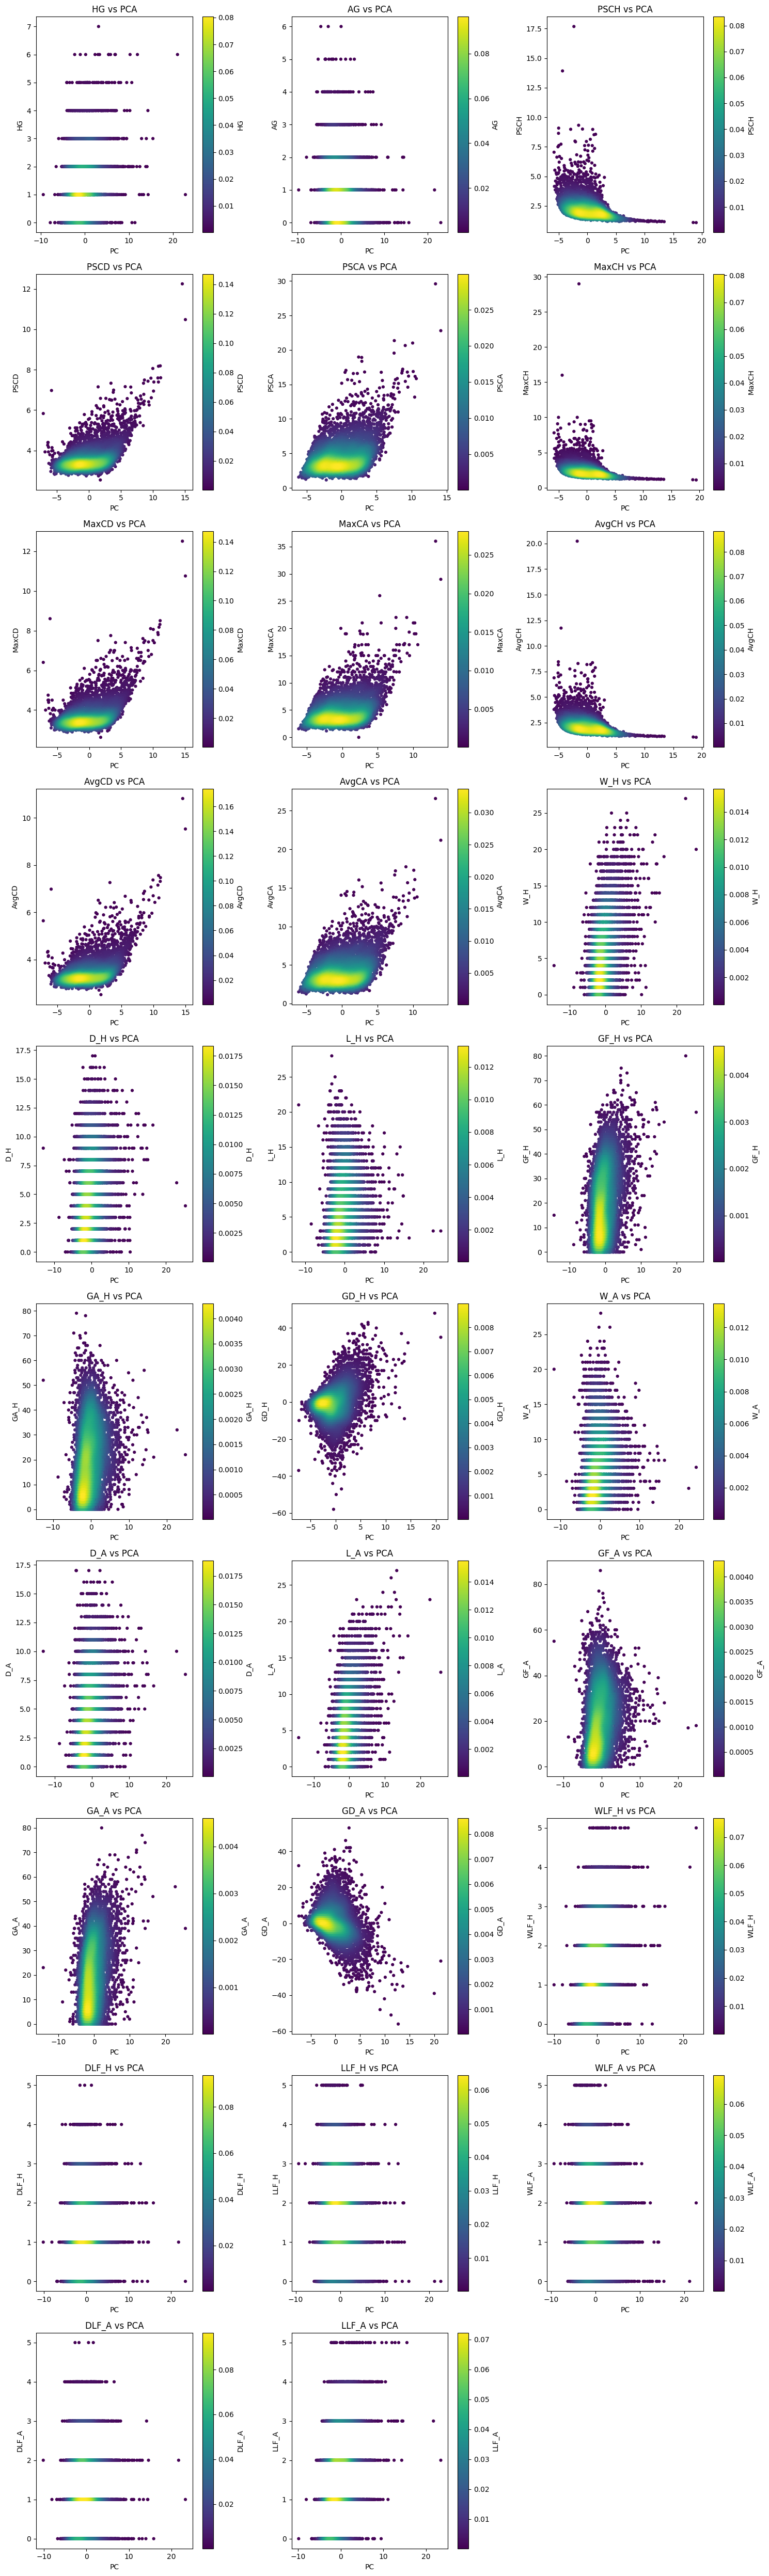

In [17]:
def plot_pca(df):
    total_cols = len(df.columns)
    n_cols = 3
    n_rows = ((total_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    for idx, col in enumerate(df.columns):   
        
        temp_df = df.drop(col, axis=1)
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(temp_df)
        
        pca = PCA(n_components=1)
        X = pca.fit_transform(X_scaled)

        # Calculating the data density
        x = X.ravel()
        y = df[col].values
        xy = np.vstack([x, y])
        z = gaussian_kde(xy)(xy) 
        i = z.argsort()
        x, y, z = x[i], y[i], z[i]

        ax = axes[idx]
        sc = ax.scatter(x, y, c=z, s=20, cmap="viridis", edgecolor="none")
        ax.set_title(f'{col} vs PCA')
        ax.set_xlabel("PC")
        ax.set_ylabel(col)
        plt.colorbar(sc, ax=ax, label=col)

    # Remove unused subplots if any
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_pca(numerical_df.drop(1891))

O PCA mostra a relação dos demais atributos em relação ao comparado atualmente. Com a sua visualização, percebe-se que uma regressão linear simples pode não ser tão eficiente, mesmo para a suavização de ruídos em etapas futuras do projeto

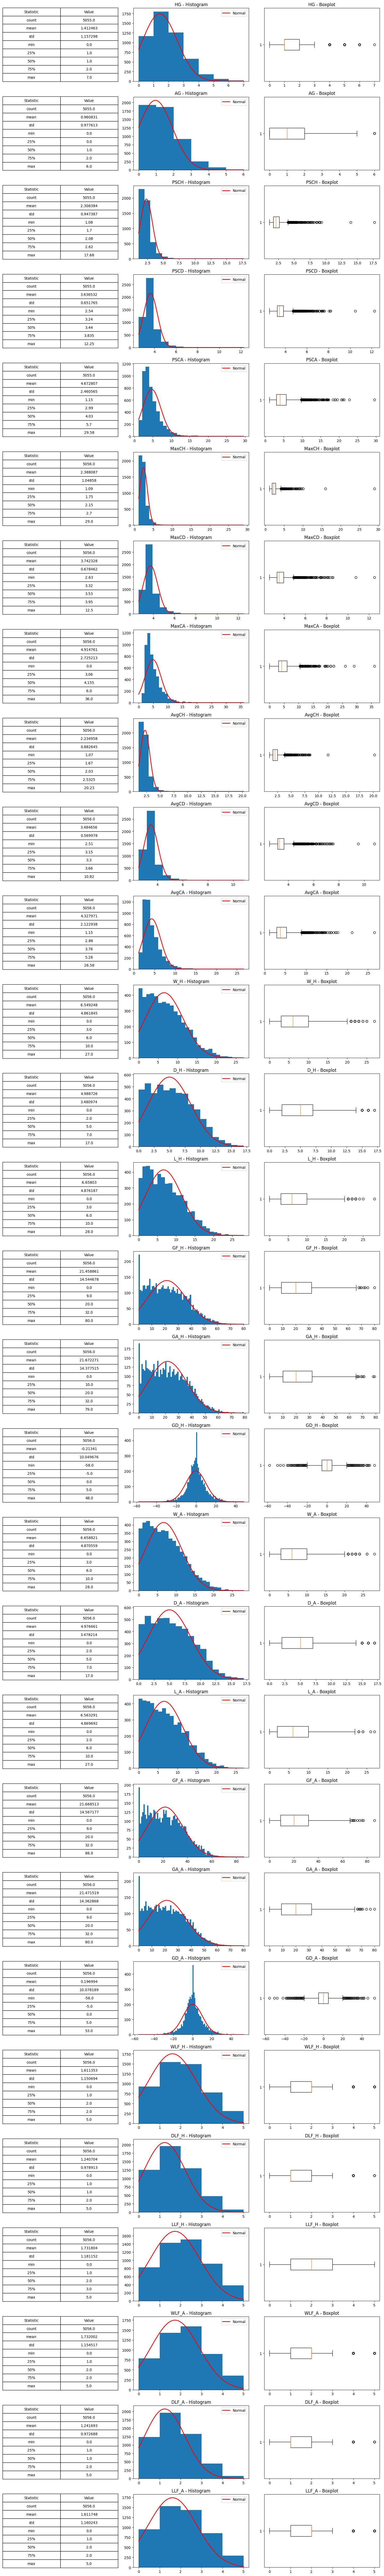

In [18]:
def describe_histogram_boxplot(df):
    n_attributes = len(df.columns)
    fig, axes = plt.subplots(n_attributes, 3, figsize=(15, 100))
    axes = axes.reshape(n_attributes, 3)  # reshape to 2D array [rows][cols]

    boxplots = {}

    for idx, attribute in enumerate(numerical_df.columns):
        # Table
        ax_table = axes[idx][0]
        ax_table.axis("off")
        
        stats = df[attribute].describe().to_dict()
        stats = {k: round(v, 6) for k, v in stats.items()}
        table_data = [[k, str(v)] for k, v in stats.items()]

        table = ax_table.table(cellText=table_data, colLabels=["Statistic", "Value"], loc='center', cellLoc="center")
        table.scale(1, 1.5)
        for _, cell in table.get_celld().items():
            cell.set_fontsize(10)

        # Histogram
        ax_hist = axes[idx][1]
        data = df[attribute].dropna()
        
        bins = int(abs(data.min()) + data.max())
        _, bin_edges, _ = ax_hist.hist(data, bins=bins)
        ax_hist.set_title(f"{attribute} - Histogram")
        
        # Adding normal distribution on the histogram
        mu, sigma = data.mean(), data.std(ddof=0)
        x = np.linspace(data.min(), data.max(), 500)
        pdf = norm.pdf(x, loc=mu, scale=sigma)
        bin_width = bin_edges[1] - bin_edges[0]
        normal_curve = pdf * len(data) * bin_width
        ax_hist.plot(x, normal_curve, color="red", lw=2, label="Normal")  
        ax_hist.legend()                                                   

        # Boxplot
        ax_box = axes[idx][2]
        bp = ax_box.boxplot(df[attribute].dropna(), vert=False, whis=1.5)
        ax_box.set_title(f"{attribute} - Boxplot")

        Q1 = df[attribute].quantile(0.25)
        Q3 = df[attribute].quantile(0.75)
        AIQ = Q3 - Q1

        boxplots[attribute] = {
            "min": bp["whiskers"][0].get_xdata()[1], 
            "max": bp["whiskers"][1].get_xdata()[1],
            "Q1": Q1,
            "Q3": Q3,
            "AIQ": AIQ 
        }

    plt.tight_layout()
    plt.show()

    return boxplots

boxplots = describe_histogram_boxplot(numerical_df)

Percebemos que todos os dados que representam odds de casas de apostas e os dados que representam saldo de gols (GD - goals difference) apresentam uma grande quantidade de outliers. 

No caso das odds definidas pelas casas de aposta, os valores dificilmente são maiores que 3, uma vez que o campeonato brasileiro é um dos mais equilibrados do mundo. Entretanto, se juntarmos todas as partidas que ocorreram de 2012 até hoje, encontramos algumas que existe um favoritismo grande de um time para outro, por exemplo quando um time com um alto investimento enfrenta um que subiu da série B naquele ano. Portanto, a quantidade grande de outliers nesses atributos pode ser explicada pelo fato de que quando um valor de odd sai do intervalo entre aproximadamente 1 e 3 já é considerado uma exceção quando comparado com a maioria das partidas nesse período de 13 anos e 6 meses. 
Podemos confirmar essas informações pelos histogramas referentes a esses atributos, que tem sempre um concentração maior nesse intervalo, variando para valores mais baixos quando se trata de times da casa e para valores um pouco maiores quando se trata de empate e de times de fora, já que no geral existe sempre um leve favoritismo para os times que estão jogando em seu estádio ao lado de sua torcida. 

Já para o caso do saldo de gols dos times, nós encontramos uma média que não distoa muito de 0 que representa os times mais centralizados na tabela do campeonato, porém todo ano temos os times do topo e os times que serão rebaixados que acabam tendo um saldo de gols diferentes dos demais, tanto para positivamente, já que os times do topo sofrem poucos gols e fazem muitos, quanto para negativamente, já que os times da parte inferior da tabela costumam sofrer muitos gols e fazer poucos.

Quando olhamos para os gols feitos pelos times da casa e de fora, podemos ver tanto pelo boxplot, quando pelo histograma e pela tabela de informações que dificilmente os times fazem mais que 3 gols em uma partida, mas diferente das odds e da diferença de gols, praticamente todos os dados seguem esse padrão e os casos em que vemos os times fazendo um número de gols diferentes são extremamente raros. Não é por acaso que a partir de 3 gols, os expectadores de futebol já consideram goleada, porque não é algo comum de se ver.

Pros casos dos números de vitórias, de empates e de derrotas dos times no campeonato, esses são valores extremamente variados, principalmente pela forma que temos nossos dados organizados. Em cada amostra, que representa uma partida, temos esses números calculados apenas até aquela respectiva rodada da temporada, portanto, além da variação esperadas desses números entre os times, existe a variação para cada rodada das 14 temporadas abordadas nesse dataset. Com isso, o limite inferior e superior dos boxplots tem um intervalo maior, ocasionando também em menos valores considerados outliers.

## c) Valores possíveis para atributos nominais e suas distribuições de probabilidades

In [19]:
for attribute in categorical_data:
    print(f"{df[attribute].value_counts(normalize=True)}")
    print("\n")

Season
2012    0.075158
2013    0.075158
2014    0.075158
2015    0.075158
2016    0.075158
2017    0.075158
2018    0.075158
2019    0.075158
2020    0.075158
2021    0.075158
2022    0.075158
2023    0.075158
2024    0.075158
2025    0.022943
Name: proportion, dtype: float64


Home
33    0.050237
17    0.050040
3     0.050040
11    0.050040
18    0.049842
21    0.046479
22    0.046084
32    0.046084
27    0.046084
1     0.045095
6     0.042326
5     0.038766
14    0.038766
35    0.035008
12    0.033821
34    0.031052
20    0.026305
10    0.026305
19    0.023734
36    0.023734
2     0.022547
7     0.020174
9     0.019976
0     0.018790
29    0.018790
16    0.015032
4     0.015032
15    0.015032
24    0.012460
13    0.011274
30    0.007516
26    0.007516
23    0.003758
31    0.003758
28    0.003758
8     0.003758
25    0.000989
Name: proportion, dtype: float64


Away
18    0.050040
11    0.050040
3     0.050040
33    0.049842
17    0.049842
22    0.046479
32    0.046479
27    0.046282


[]

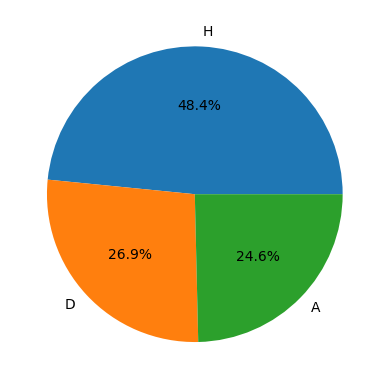

In [20]:
x = df["Res"].value_counts(normalize=True).values
labels = df["Res"].value_counts(normalize=True).keys() 
plt.pie(x, labels=labels, autopct='%1.1f%%')
plt.plot()

Os dados de season aparecem de forma semelhante pois as temporadas possuem valores iguais de partidas

Home e Away irão variar devido ao rebaixamento dos times durante o período de tempo

Por outro lado, é interessante ver que os times que jogaram como mandantes possuem um maior aproveitamento das partidas

## d) Identificação de valores ausentes, aberrantes e inconsistentes
O dataset, antes de passar por este notebook é pré-processasdo no início desse arquivo, onde algumas colunas são removidas devido à grande quantidade de valores nulos e pela grande dificuldade que seria para gerar novos valores, uma vez que a quantidade de linhas não nulas são muito baixas. Essas colunas são: "BFECH", "BFECD", "BFECA".

In [21]:
def check_null_itens(df):
    for index, value in df.isnull().any().items():    
        if value:
            print(f"{index} contains {df[index].isnull().sum()} null values")

check_null_itens(df)

HG contains 1 null values
AG contains 1 null values
Res contains 1 null values
PSCH contains 1 null values
PSCD contains 1 null values
PSCA contains 1 null values


Após uma investigação, descobriu-se que os valores nulos correspondem a uma partida da última rodada do campeonato Brasileiro do ano de 2016, entre Chapecoense e Atlético-MG, no dia 11/12/2016. A inexistência dos valores deve-se ao fato de que a partida não aconteceu, e ambas as equipes sofreram um [WO duplo](https://www.uol.com.br/esporte/futebol/campeonatos/brasileiro/serie-a/ultimas-noticias/2016/12/11/chapecoense-x-atletico-mg.htm).

In [22]:
for attribute in numerical_df:
    values = df[attribute].dropna()
    lower_bound = boxplots[attribute]["min"]
    upper_bound = boxplots[attribute]["max"]

    outliers = values[(values < lower_bound) | (values > upper_bound)]

    print(f"Outliers in {attribute}:")
    print(lower_bound, upper_bound)
    print(outliers)
    print("-" * 40)

Outliers in HG:
0.0 3.0
3       4.0
24      4.0
42      4.0
52      5.0
74      4.0
       ... 
4995    4.0
5002    4.0
5010    5.0
5018    4.0
5046    5.0
Name: HG, Length: 250, dtype: float64
----------------------------------------
Outliers in AG:
0.0 5.0
1948    6.0
4430    6.0
4619    6.0
Name: AG, dtype: float64
----------------------------------------
Outliers in PSCH:
1.08 4.0
290     4.78
333     4.94
340     5.19
365     4.92
414     4.05
        ... 
4987    4.40
5006    6.68
5007    4.85
5025    4.11
5026    4.04
Name: PSCH, Length: 252, dtype: float64
----------------------------------------
Outliers in PSCD:
2.54 4.72
16      4.76
17      4.74
24      4.99
52      5.09
76      5.09
        ... 
4933    5.01
4935    5.20
4976    6.58
4990    4.77
5046    5.10
Name: PSCD, Length: 323, dtype: float64
----------------------------------------
Outliers in PSCA:
1.15 9.74
52      10.75
134     12.11
190     10.72
238     11.05
247     11.09
        ...  
4881    14.61
4929    10

## e) Correlação dos atributos numéricos

In [23]:
temp_df = df.copy()

temp_df["Res"] = temp_df["Res"].map({"H": 1, "D": 0, "A": -1})
temp_df = temp_df.drop(["Season", "Home", "Away"], axis=1)

correlations = temp_df.corr(method='pearson')
correlations

,HG,AG,Res,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,W_H,D_H,L_H,GF_H,GA_H,GD_H,W_A,D_A,L_A,GF_A,GA_A,GD_A,WLF_H,DLF_H,LLF_H,WLF_A,DLF_A,LLF_A
HG,1.000000,0.022502,0.609903,-0.234182,0.238865,0.259885,-0.221974,0.238157,0.260289,-0.232520,0.238688,0.265134,0.099719,0.004118,-0.071603,0.075775,-0.039135,0.165592,-0.048683,0.003301,0.076481,-0.022004,0.061722,-0.119724,0.080817,-0.019903,-0.080781,-0.074636,-0.010760,0.063898
AG,0.022502,1.000000,-0.609608,0.196328,-0.071859,-0.167029,0.186747,-0.076880,-0.162312,0.194164,-0.075358,-0.167931,-0.038114,-0.010444,0.035741,-0.020575,0.032824,-0.076706,0.059736,-0.022806,-0.050684,0.055927,-0.021112,0.110868,-0.045031,-0.003169,0.060985,0.077145,0.003910,-0.061553
Res,0.609903,-0.609608,1.000000,-0.286103,0.177062,0.264299,-0.271398,0.181175,0.262137,-0.283255,0.179994,0.269534,0.082281,0.004257,-0.082960,0.054785,-0.056967,0.160725,-0.073064,0.015698,0.060667,-0.055819,0.034853,-0.130289,0.073071,-0.004339,-0.092328,-0.094784,-0.006527,0.071273
PSCH,-0.234182,0.196328,-0.286103,1.000000,-0.332317,-0.664403,0.986804,-0.329435,-0.647929,0.995408,-0.325934,-0.674721,-0.214776,0.008757,0.209730,-0.156885,0.136406,-0.422039,0.213585,-0.002177,-0.212513,0.159542,-0.134089,0.421508,-0.227982,0.003105,0.228081,0.250266,0.008198,-0.243535
PSCD,0.238865,-0.071859,0.177062,-0.332317,1.000000,0.851583,-0.296831,0.986370,0.859345,-0.332852,0.986736,0.850745,0.278878,0.041303,-0.064241,0.257090,0.019636,0.343876,-0.063642,0.055679,0.266460,0.006476,0.239305,-0.331594,0.229137,-0.031046,-0.160214,-0.156846,-0.024512,0.212033
PSCA,0.259885,-0.167029,0.264299,-0.664403,0.851583,1.000000,-0.630779,0.857512,0.988122,-0.661936,0.859959,0.991896,0.262048,0.012392,-0.186205,0.198422,-0.111344,0.446296,-0.200031,0.028998,0.264129,-0.141578,0.182646,-0.464738,0.262566,-0.011046,-0.237903,-0.257853,-0.008949,0.270202
MaxCH,-0.221974,0.186747,-0.271398,0.986804,-0.296831,-0.630779,1.000000,-0.290985,-0.616914,0.993785,-0.290086,-0.642506,-0.207389,0.011665,0.208892,-0.151184,0.136299,-0.413800,0.213581,-0.000425,-0.205360,0.160081,-0.127724,0.413409,-0.220011,0.003490,0.220352,0.246263,0.006819,-0.238520
MaxCD,0.238157,-0.076880,0.181175,-0.329435,0.986370,0.857512,-0.290985,1.000000,0.868184,-0.329455,0.987982,0.858457,0.279579,0.039489,-0.078611,0.254681,0.007509,0.357852,-0.074958,0.055504,0.263360,-0.003905,0.233371,-0.338232,0.234860,-0.029876,-0.172036,-0.164767,-0.021767,0.212369
MaxCA,0.260289,-0.162312,0.262137,-0.647929,0.859345,0.988122,-0.616914,0.868184,1.000000,-0.647604,0.869948,0.991117,0.267571,0.009820,-0.187176,0.202275,-0.110648,0.451046,-0.197836,0.030359,0.263840,-0.139331,0.182707,-0.461775,0.267419,-0.013606,-0.240066,-0.256636,-0.006354,0.267432
AvgCH,-0.232520,0.194164,-0.283255,0.995408,-0.332852,-0.661936,0.993785,-0.329455,-0.647604,1.000000,-0.325935,-0.673628,-0.214826,0.013122,0.213553,-0.156140,0.139445,-0.425474,0.218174,0.000103,-0.212030,0.163096,-0.132552,0.424648,-0.229682,0.006124,0.227907,0.252425,0.008139,-0.245049


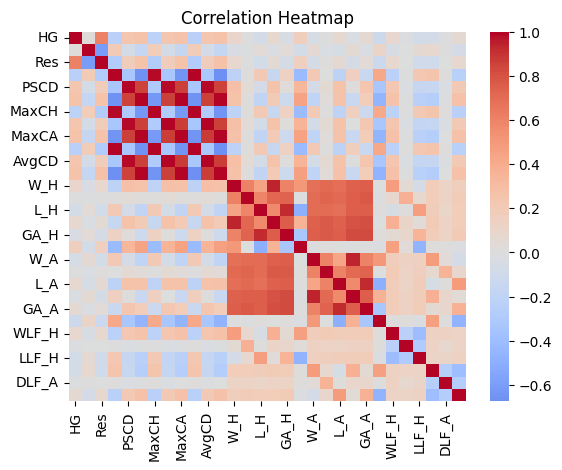

In [24]:
sns.heatmap(correlations, annot=False, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

In [25]:
weak_correlations = {}
for index_row, row in correlations.iterrows():
    for index_col in row.keys():
        if -0.2 < row[index_col] < 0.2:

            if index_row not in weak_correlations:
                weak_correlations[index_row] = []
            
            correlation = {index_col: row[index_col]}
            weak_correlations[index_row].append(correlation)


strong_correlations = {}
for index_row, row in correlations.iterrows():
    for index_col in row.keys():
        if (0.8 < row[index_col] < 1.0) or (-1.0 < row[index_col] < -0.8):

            if index_row not in strong_correlations:
                strong_correlations[index_row] = []
            
            correlation = {index_col: row[index_col]}
            strong_correlations[index_row].append(correlation)

print(weak_correlations)
print("")
print(strong_correlations)

{'HG': [{'AG': np.float64(0.022502050641982674)}, {'W_H': np.float64(0.0997189030387792)}, {'D_H': np.float64(0.004118128151412579)}, {'L_H': np.float64(-0.07160264630299465)}, {'GF_H': np.float64(0.07577483607719203)}, {'GA_H': np.float64(-0.03913465352328979)}, {'GD_H': np.float64(0.16559217216855884)}, {'W_A': np.float64(-0.04868250627889874)}, {'D_A': np.float64(0.0033011523257785408)}, {'L_A': np.float64(0.07648074799961344)}, {'GF_A': np.float64(-0.022003798305792677)}, {'GA_A': np.float64(0.06172210954127603)}, {'GD_A': np.float64(-0.11972384869147461)}, {'WLF_H': np.float64(0.08081652075010132)}, {'DLF_H': np.float64(-0.019902858424279284)}, {'LLF_H': np.float64(-0.08078105555533817)}, {'WLF_A': np.float64(-0.07463624167948744)}, {'DLF_A': np.float64(-0.01076040141027828)}, {'LLF_A': np.float64(0.0638978834966296)}], 'AG': [{'HG': np.float64(0.022502050641982674)}, {'PSCH': np.float64(0.19632757744396592)}, {'PSCD': np.float64(-0.07185922661031093)}, {'PSCA': np.float64(-0.1670

Consideramos uma correlação forte quando o valor é maior que 0.8, visto que esse valor sugere que uma variável pode agregar a mesma informação que a outra dentro de um modelo.

Podemos observar que os três tipos de atributos de odds de casa de aposta presentes no dataset, odds da Pinnacle Sports, odds máximas do mercado e valores médios das odds no mercado, têm uma forte correlação tanto para o caso de vitória do time mandante, quanto para o caso de empate e para o caso de vitória do time visitante. Isso significa, por exemplo, que quanto maior o valor da odd da Pinnacle Sports para a vitória do time mandante, maior a odd máxima e o valor médio da odd no mercado para a vitória do mandante. Isso, no caso, é um comportamento esperado, já que as odds seguem um padrão por analisarem o mesmo contexto de campeonato. Portanto, manter apenas um dos tipos de odd pode ser suficiente para trazer a informação ao modelo do que é esperado para aquela partida pelas casas de aposta.

Da mesma forma, podemos observar uma correlação forte entre os atributos de números de vitórias do time e número de gols feitos por ele, e entre os atributos de números de derrotas do time e números de gols sofridos por ele, tanto no caso do time mandante, quanto no caso do time visitante. Isso é explicado pelo fato de que se espera que times que venceram mais tenham também marcado mais gols, e times que tiveram mais derrotas também tenham sofrido mais gols.

Por fim, vemos uma correlação forte aparecendo entre o número de gols feitos pelo mandante da partida e gols feitos e sofridos pelo visitante. E o mesmo para o contrário. Isso ocorre pela organização do nosso dataset, em que cada rodada apresentam dados estatísticos dos dois times até aquele momento do campeonato. Logo, é normal que a cada rodada, o número de gols feitos e sofridos de ambos os times crescam, trazendo uma correlação para esses 4 atributos. 

Para uma correlação fraca, temos atributos que não tem dependência um com outro. Podemos perceber por exemplo que o número de gols marcados pelo time mandante e pelo time visitante na partida tem correlação fraca com a maioria das outras variáveis. Isso porque o número de gols feitos por eles não é necessariamente explicado por nenhuma delas isoladamente.

# 2 - Limpeza e transformação dos dados

## a) Removendo valores nulos
O dado de index 1891 corresponde à partida entre Chapecoense e Atlético-MG (Galo) que não ocorreu, como já foi explicado na letra D da parte 1. Por isso tal partida será removida do conjunto de dados

In [26]:
df = df.drop(1891)
check_null_itens(df) # if no print is made, then there is no null values

## b) Suavização de ruídos

O uso de regressão linear para a normalização não gerou resultados satisfatórios, mantendo outliers ainda muito altos

Utilizando a regra de Freedman-Diaconis para determinar o número de bins, que diminui a chance dos dados se transformarem em uma distribuição normal, como ocorre na regra de Scott

$$
\text{Number of bins} = \frac{\max(x) - \min(x)}{2 \cdot {IQR} \cdot {n^{-1/3}}}
$$

In [27]:
def freedman_diaconis_rule(data, iqr):
    data = data.to_numpy()
    num_bins = int((data.max()-data.min()) / (2*iqr*len(data)**(-1/3)))
    return num_bins

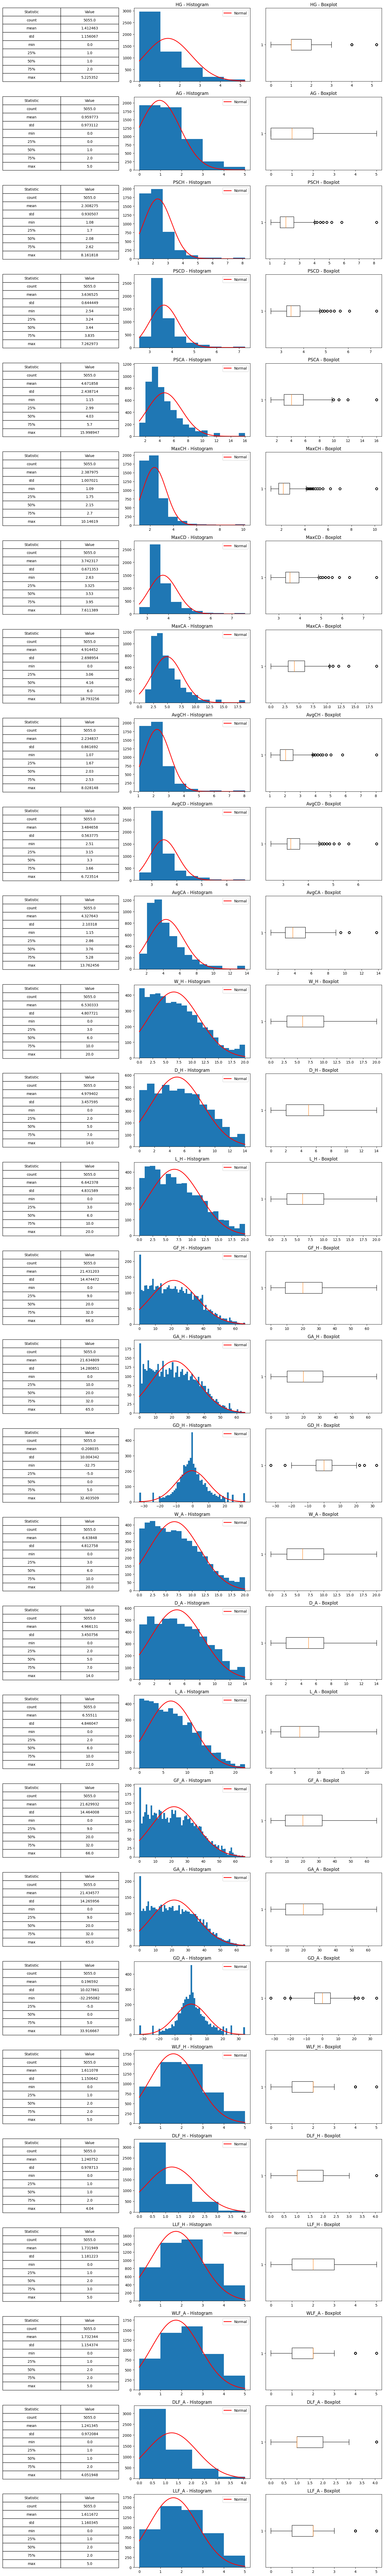

In [28]:
da = df.copy()
# numerical_columns = list(set(da.columns.to_list()) - set(categorical_data))

for col in numerical_df.columns:
    da[col] = da[col].astype(np.float64)

    num_bins = freedman_diaconis_rule(da[col], boxplots[col]["AIQ"])
    value_bins = pd.qcut(da[col], num_bins, duplicates="drop").value_counts()

    # Saving the intervals
    bin_dict = {}
    for interval, count in value_bins.items():
        bin_dict[(interval.left, interval.right)] = {"count": count, "avg": 0}

    # Adding each value into the correct interval
    for value in da[col]:
        for (left, right) in bin_dict:
            if left < value and value <= right: 
                bin_dict[(left, right)]["avg"] += value
                break

    # Calculating the average value of the bin
    for key in bin_dict.keys():
        if bin_dict[key]["count"] != 0:
            bin_dict[key]["avg"] = bin_dict[key]["avg"] / bin_dict[key]["count"]
    
    # Replacing outliers with bin average
    for idx, value in da[col].items():
        if value > boxplots[col]["max"] or value < boxplots[col]["min"]:
            for (left, right), data in bin_dict.items():
                if left < value and value <= right:
                    da.at[idx, col] = data["avg"]
                    break
    
describe_histogram_boxplot(da[numerical_df.columns])
print("")

O qcut foi escolhido para aproximar os outliers que estão muito longe dos dados normais, suavizando-os.

Os outliers foram suavizados e, àqueles que possuiam valores muito discrepantes, foram reduzidos significativamente, como ocorreu nos dados do MaxCH, onde passaram de 29 para 10, por exemplo, ficando extremamente mais próximos dos demais valores do atributo.

Além disso, em alguns dados, como no AG, não há mais a presença de outliers, demonstrando a eficiência do qcut.

No GD_A e no GD_H, os outliers ainda estão bem presentes. Mesmo sendo suavizados, passando de -56 para -32, por exemplo, a grande presença dos mesmos nos valores mais extremos ainda deixou os dados com bastantes valores aberrantes, ainda sendo notável uma grande presença deles nos extremos.


## c) Resolvendo inconsistênicas
Não há mais inconsistências nos dados, uma vez que a partida que apresentava já foi removida

## d) Transformando atributos categóricos nominais em vetores numéricos

In [29]:
df = pd.get_dummies(df, columns=["Res"], prefix="Res", dtype=int, drop_first=True) # Transformando em on-hot-encoded

df = df.drop(["Season"], axis=1) # It is a numerical data, but it does not represent very useful information, since the season statistics are already incorporated in the last columns of the table

df = df.drop(["HG", "AG"], axis=1) # I won't know how many goals each team will score in the match when I predict the result, so it's an attribute that only served to build other statistical attributes

# e) Transformação de atributos categóricos ordinais
Não há atributos categóricos ordinais nos dados

# f) Normalização de valores numéricos.

In [30]:
# min-max normalization
numerical_columns = list(set(da.columns.to_list()) - set(categorical_data) - set(["HG", "AG"]))
df[numerical_columns] = (df[numerical_columns] - df[numerical_columns].min()) / (df[numerical_columns].max() - df[numerical_columns].min())

df


,Home,Away,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,W_H,D_H,L_H,GF_H,GA_H,GD_H,W_A,D_A,L_A,GF_A,GA_A,GD_A,WLF_H,DLF_H,LLF_H,WLF_A,DLF_A,LLF_A,Res_D,Res_H
0,27,30,0.040361,0.135942,0.144214,0.024006,0.125633,0.147500,0.032359,0.119134,0.147464,0.000000,0.000000,0.000000,0.0000,0.000000,0.547170,0.000000,0.000000,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0,1,0
1,34,17,0.105422,0.087539,0.053816,0.062343,0.080041,0.075000,0.079332,0.086643,0.056233,0.000000,0.000000,0.000000,0.0000,0.000000,0.547170,0.000000,0.000000,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2,16,26,0.031325,0.154480,0.195920,0.020781,0.143870,0.200556,0.027140,0.139591,0.176563,0.000000,0.000000,0.000000,0.0000,0.000000,0.547170,0.000000,0.000000,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0,0,1
3,6,33,0.084940,0.083419,0.070348,0.050161,0.077001,0.087500,0.066806,0.090253,0.066457,0.000000,0.000000,0.000000,0.0000,0.000000,0.547170,0.000000,0.000000,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0,0,1
4,11,18,0.053012,0.101957,0.114668,0.031172,0.091185,0.122500,0.042797,0.098676,0.107747,0.000000,0.000000,0.000000,0.0000,0.000000,0.547170,0.000000,0.000000,0.000000,0.000000,0.0000,0.513761,0.0,0.0,0.0,0.0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5051,36,14,0.145783,0.052523,0.043616,0.089932,0.052685,0.066389,0.119520,0.062575,0.044436,0.074074,0.235294,0.178571,0.1250,0.177215,0.509434,0.250000,0.117647,0.074074,0.197674,0.1000,0.596330,0.2,0.2,0.6,0.8,0.2,0.0,1,0
5052,19,32,0.071687,0.064882,0.086528,0.043712,0.057751,0.100278,0.060543,0.070999,0.087692,0.074074,0.235294,0.178571,0.1250,0.189873,0.500000,0.071429,0.117647,0.259259,0.093023,0.1500,0.477064,0.2,0.2,0.6,0.2,0.2,0.6,0,0
5053,21,11,0.078313,0.039135,0.088991,0.046220,0.047619,0.102222,0.065240,0.045728,0.090444,0.148148,0.176471,0.142857,0.1375,0.177215,0.518868,0.142857,0.176471,0.148148,0.139535,0.1750,0.495413,0.6,0.2,0.2,0.4,0.4,0.2,1,0
5054,3,22,0.050000,0.087539,0.122758,0.030813,0.083080,0.131944,0.042797,0.090253,0.124656,0.148148,0.294118,0.071429,0.1375,0.126582,0.556604,0.071429,0.294118,0.148148,0.139535,0.2000,0.477064,0.6,0.4,0.0,0.0,0.4,0.6,0,1


In [32]:
df.to_csv('BRA-pre-processed.csv', index=False)